# 03 Scaling Runtime

This notebook visualizes runtime and memory scaling with:

- `M`: number of transmit antennas
- `K`: number of users

Input: `result/table/03_scaling_runtime.csv`

Outputs: PDF figures in `result/figure/` and aggregated tables in `result/table/`.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------------------------------
# Fix: Handle paths for both Script (.py) and Jupyter Notebook (.ipynb)
# -----------------------------------------------------------------------------
try:
    # This works when running as a script
    current_path = Path(__file__).resolve()
    ROOT = current_path.parents[1]
except NameError:
    # This works in Jupyter Notebook
    # Note: Path.cwd() returns the directory where the notebook is running.
    # If your notebook is in "root/src/", .parents[0] gives "root/"
    # Adjust the number of parents based on your folder structure.
    current_path = Path.cwd()
    ROOT = current_path.parents[0]  # Change [0] to [1] if needed based on notebook location

# Verify the path is correct
print(f"Current ROOT: {ROOT}")

tbl_dir = ROOT / "result" / "table"
fig_dir = ROOT / "result" / "figure"
fig_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Load Data
# -----------------------------------------------------------------------------
# Ensure the file exists before reading to avoid FileNotFoundError
csv_path = tbl_dir / "03_scaling_runtime.csv"
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(df.head())
else:
    print(f"Error: File not found at {csv_path}")

Current ROOT: /home/leiyo/GitHub/TOAH
   seed method  avg_sum_queue  p95_max_queue  avg_sense_u  p95_sense_u  \
0   123   TOAH     226.096420     231.994400     2.953144     7.444100   
1   123   TOAH     399.874695     211.997101     4.488178    18.365099   
2   123   TOAH     840.274780     230.047882     3.918979    15.967586   
3   123   TOAH    1202.880615     202.999405     4.922278    24.079515   
4   123   TOAH     226.094101     231.999863     6.338534    36.208794   

   alpha_total_variation  switch_count  deadline_violation_rate  avg_slot_ms  \
0               0.644752             1                    0.870  2011.686670   
1               1.284912             1                    0.840  2923.124250   
2               1.266022             1                    0.845  4901.687438   
3               1.067325             1                    0.845  6896.653011   
4               0.500000             0                    0.870  1975.218785   

   total_time_s device  csi_error_st

In [3]:
# Aggregate mean/std over runs per (M,K)
metrics = ["avg_slot_ms", "peak_mem_mb", "avg_sum_queue", "avg_sense_u"]

agg = df.groupby(["M", "K"])[metrics].agg(["mean", "std"]).reset_index()
agg.columns = ["M", "K"] + [f"{m}_{s}" for m in metrics for s in ["mean", "std"]]

out_table = tbl_dir / "03_scaling_runtime_table.csv"
agg.to_csv(out_table, index=False)
print("Saved table:", out_table)

agg.head()


Saved table: /home/leiyo/GitHub/TOAH/result/table/03_scaling_runtime_table.csv


,M,K,avg_slot_ms_mean,avg_slot_ms_std,peak_mem_mb_mean,peak_mem_mb_std,avg_sum_queue_mean,avg_sum_queue_std,avg_sense_u_mean,avg_sense_u_std
0,8,2,1924.303823,76.413551,96.646484,0.0,207.021016,16.888260,1.738510,1.055641
1,8,4,2803.203861,108.483891,114.246094,0.0,408.501923,10.558705,9.923114,9.743693
2,8,8,4730.655256,148.148443,149.474121,0.0,838.172323,20.142522,38.421782,56.170294
3,8,12,6628.613115,232.269422,184.687012,0.0,1181.553914,18.988711,9.481444,8.008152
4,16,2,1910.067681,56.825758,96.646484,0.0,207.019557,16.887365,15.914828,13.961650


Saved: /home/leiyo/GitHub/TOAH/result/figure/03_heatmap_runtime.pdf


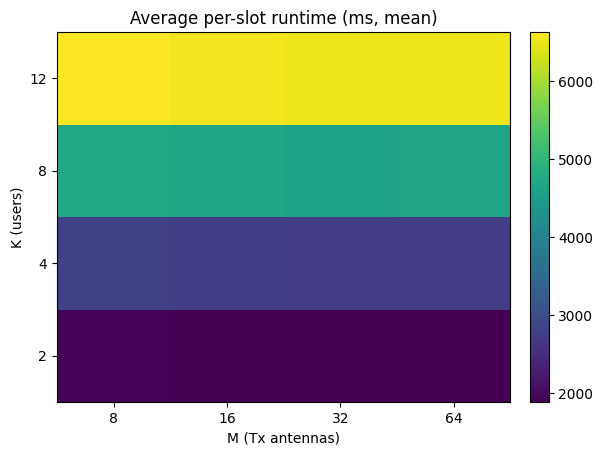

In [4]:
# Heatmap of runtime
piv = agg.pivot(index="K", columns="M", values="avg_slot_ms_mean")
plt.figure()
im = plt.imshow(piv.values, aspect="auto", origin="lower")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(piv.columns)), piv.columns)
plt.yticks(range(len(piv.index)), piv.index)
plt.xlabel("M (Tx antennas)")
plt.ylabel("K (users)")
plt.title("Average per-slot runtime (ms, mean)")
out = fig_dir / "03_heatmap_runtime.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)


Saved: /home/leiyo/GitHub/TOAH/result/figure/03_runtime_vs_M.pdf


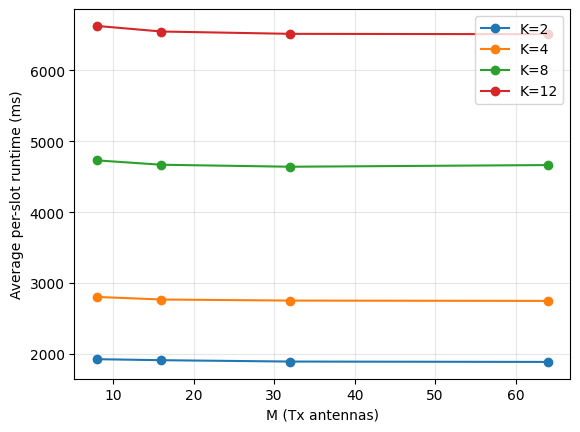

In [5]:
# Runtime vs M for each K
plt.figure()
for k in sorted(agg["K"].unique()):
    sub = agg[agg["K"] == k].sort_values("M")
    plt.plot(sub["M"], sub["avg_slot_ms_mean"], marker="o", label=f"K={k}")
plt.xlabel("M (Tx antennas)")
plt.ylabel("Average per-slot runtime (ms)")
plt.legend()
plt.grid(True, alpha=0.3)
out = fig_dir / "03_runtime_vs_M.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)


Saved: /home/leiyo/GitHub/TOAH/result/figure/03_peak_memory_vs_M.pdf


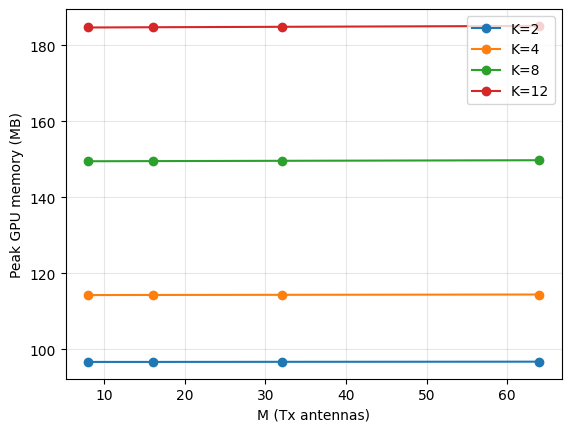

In [6]:
# Peak GPU memory vs M for each K (if available)
if np.isfinite(agg["peak_mem_mb_mean"]).any():
    plt.figure()
    for k in sorted(agg["K"].unique()):
        sub = agg[agg["K"] == k].sort_values("M")
        plt.plot(sub["M"], sub["peak_mem_mb_mean"], marker="o", label=f"K={k}")
    plt.xlabel("M (Tx antennas)")
    plt.ylabel("Peak GPU memory (MB)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    out = fig_dir / "03_peak_memory_vs_M.pdf"
    plt.savefig(out, format="pdf", bbox_inches="tight")
    print("Saved:", out)
else:
    print("No GPU memory stats found (likely ran on CPU).")


Saved: /home/leiyo/GitHub/TOAH/result/figure/03_bubble_runtime_vs_queue.pdf


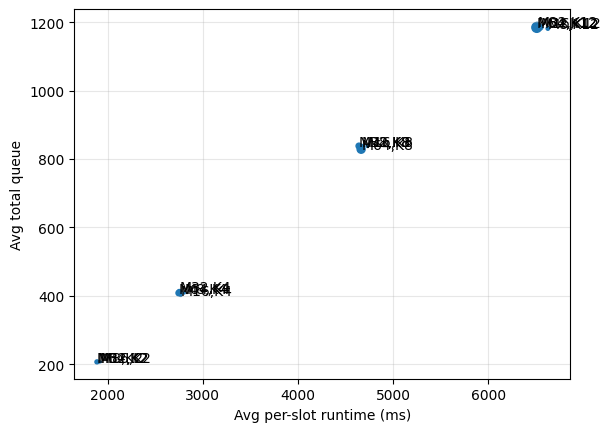

In [7]:
# Bubble-style scatter: runtime vs performance with bubble size proportional to M*K
size = (agg["M"] * agg["K"]).values.astype(float)
size = 50.0 * (size / np.max(size))

plt.figure()
plt.scatter(agg["avg_slot_ms_mean"], agg["avg_sum_queue_mean"], s=size)
for _, r in agg.iterrows():
    plt.annotate(f"M{int(r['M'])},K{int(r['K'])}", (r["avg_slot_ms_mean"], r["avg_sum_queue_mean"]))
plt.xlabel("Avg per-slot runtime (ms)")
plt.ylabel("Avg total queue")
plt.grid(True, alpha=0.3)
out = fig_dir / "03_bubble_runtime_vs_queue.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)
